# **Gamma Correction and Tone Mapping (Group 8)**

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### **Gamma Correction** UNFINISHED BBG

Gamma correction is the process of applying the power law on raw camera data. Since the human eye notices dark-area details better than bright ones, we use the power law to adjust raw camera data so it looks "natural" to our eyes on a screen. This adjustment can work in two directions:

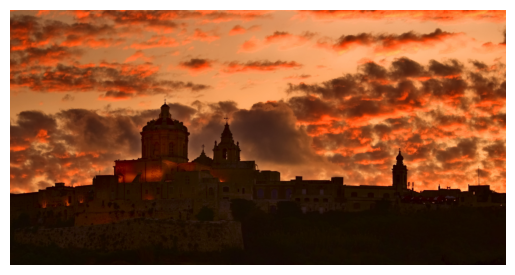

In [23]:
img = cv2.imread("Mdina-Sunset.jpg", 1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # type: ignore
plt.imshow(img)
plt.axis('off')
plt.show()

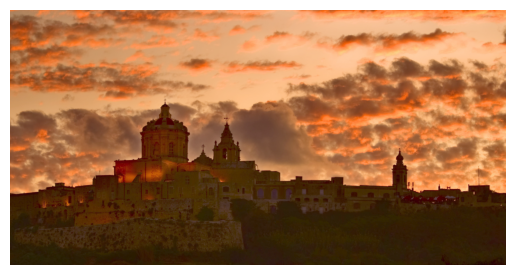

In [24]:
def powerLaw(img, gamma, c=255.0):
	img_f = img.astype(np.float64)
	s = c * (img_f / 255) ** gamma
	return np.clip(s, 0, 255).astype(np.uint8) # clip values

plt.imshow(powerLaw(img, gamma=.67))
plt.axis('off')
plt.show()

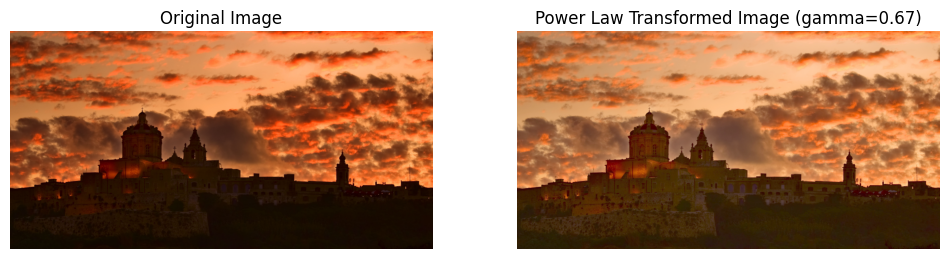

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(img)
axs[1].imshow(powerLaw(img, gamma=0.67))

axs[0].axis('off')
axs[0].set_title('Original Image')
axs[1].axis('off')
axs[1].set_title('Power Law Transformed Image (gamma=0.67)')
plt.show()

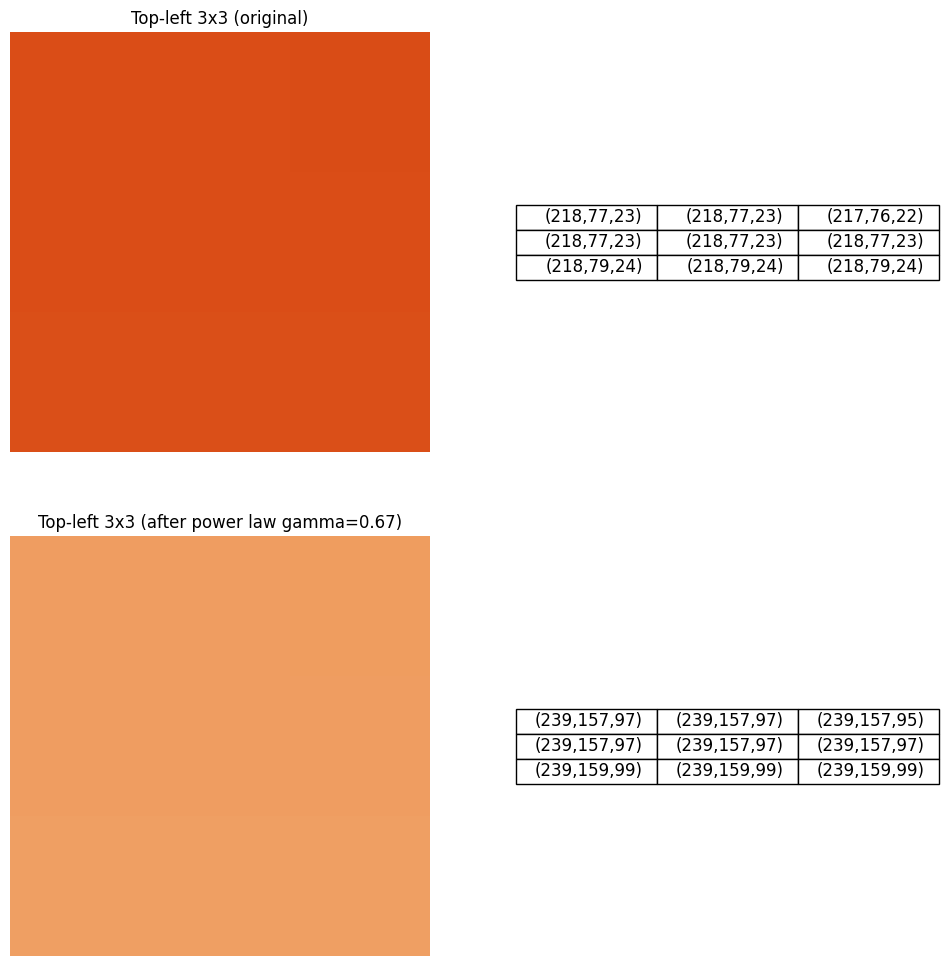

VAS


In [33]:
import pandas as pd
# SIZE
patch_size = 3
# PATCH
patch = img[:patch_size, :patch_size].copy()


fig, ax = plt.subplots(2,2, figsize=(12,12))

# extract top-left {patch_size}x{patch_size} pixels (top-left corner)
ax[0,0].imshow(patch, interpolation='nearest')
ax[0,0].set_title(f'Top-left {patch_size}x{patch_size} (original)')

# show RGB tuples in a {patch_size}x{patch_size} table
rgb_rows = [[f'({int(patch[i,j,0])},{int(patch[i,j,1])},{int(patch[i,j,2])})' for j in range(patch_size)] for i in range(patch_size)]

table1 = ax[0,1].table(
    cellText=rgb_rows,
    loc='center'
)

# Optional formatting
table1.auto_set_font_size(False)
table1.set_fontsize(12)
table1.scale(1, 1.5)

# apply power law to full image and get altered top-left {patch_size}x{patch_size}
transformed = powerLaw(img, gamma=0.4)
altered = transformed[:patch_size, :patch_size].copy()
ax[1,0].imshow(altered, interpolation='nearest')
ax[1,0].set_title(f'Top-left {patch_size}x{patch_size} (after power law gamma=0.67)')

# show altered RGB tuples in a {patch_size}x{patch_size} table
altered_rows = [[f'({int(altered[i,j,0])},{int(altered[i,j,1])},{int(altered[i,j,2])})' for j in range(patch_size)] for i in range(patch_size)]
table2 = ax[1,1].table(
    cellText=altered_rows,
    loc='center'
)

# Optional formatting
table2.auto_set_font_size(False)
table2.set_fontsize(12)
table2.scale(1, 1.5)

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[1,0].axis('off')
ax[1,1].axis('off')

plt.show()

print("VAS")

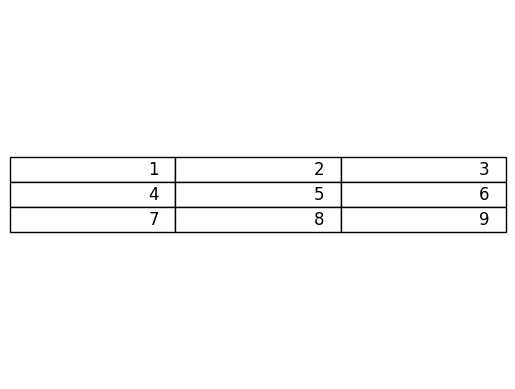

In [27]:
import matplotlib.pyplot as plt

# Example 2D list
data = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]

fig, ax = plt.subplots()

# Remove axes
ax.axis('off')

# Create table
table = ax.table(
    cellText=data,
    loc='center'
)

# Optional formatting
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)

plt.show()